# **Utility**

### interactive dropdown-based time series visualization

In [8]:
import pandas as pd

from pathlib import Path
from IPython.display import display, HTML, IFrame

In [9]:
import plotly.io as pio
pio.renderers.default = "iframe"

In [10]:
parquet_dir_up = Path("/home/sagemaker-user/data/petrochem")
u_files = list(parquet_dir_up.glob("*_u.parquet"))

In [11]:
utility_data = pd.concat([pd.read_parquet(f) for f in u_files])
utility_data.groupby('TAG').size().sort_values(ascending=False).head()

TAG
FI10203_PV    35696
FI20203_PV    35696
FI25205_PV    35696
FI40205_PV    35696
FI50205_PV    35696
dtype: int64

In [16]:
from ipywidgets import DatePicker, HBox, VBox, Dropdown, interact
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd

utility_data = pd.concat([pd.read_parquet(f) for f in u_files])

# Get min and max dates
min_date = pd.to_datetime(utility_data['Datetime']).dt.date.min()
max_date = pd.to_datetime(utility_data['Datetime']).dt.date.max()

tag_dropdown = Dropdown(options=utility_data['TAG'].unique(), description='Utility:')
start_date = DatePicker(description='Start Date:', value=min_date)
end_date = DatePicker(description='End Date:', value=max_date)

@interact(tag=tag_dropdown, start=start_date, end=end_date)
def plot_utility(tag, start, end):
    df = utility_data[utility_data['TAG'] == tag].copy()
    df['Datetime'] = pd.to_datetime(df['Datetime'])
    df['Date'] = df['Datetime'].dt.date
    equip = df['Equipment'].iloc[0]
    desc = df['Desc.'].iloc[0]
    
    # Filter by date range
    df = df[(df['Date'] >= start) & (df['Date'] <= end)]
    
    if df.empty:
        print("No data in selected range")
        return
    
    # daily_df = df.groupby('Date')['Value'].agg(['mean']).reset_index()
    # daily_df['Date'] = pd.to_datetime(daily_df['Date'])
    
    fig = px.bar(df, x='Datetime', y='Value', title=f'{tag}<br><sup>{equip} | {desc}</sup>')
    fig.update_xaxes(title_text='DateTime')
    fig.update_yaxes(title_text='Value')
    fig.add_trace(go.Scatter(
    x=df['Datetime'],
    y=df['Value'].rolling(window=24).mean(),
    mode='lines',
    name='24h Moving Avg',
    line=dict(color='red', width=2)
))
    fig.show()

#interact(plot_utility, tag=tag_dropdown, start=start_date, end=end_date)

interactive(children=(Dropdown(description='Utility:', options=('FI91501_PV', 'FI91502_PV', 'FI91503_PV', 'FI9…

In [6]:
from ipywidgets import DatePicker, Dropdown
import pandas as pd
import plotly.express as px

min_date = pd.to_datetime(utility_data['Datetime']).dt.date.min()
max_date = pd.to_datetime(utility_data['Datetime']).dt.date.max()

tag_dropdown = Dropdown(options=utility_data['TAG'].unique(), description='Utility:')
start_date = DatePicker(description='Start Date:', value=min_date)
end_date = DatePicker(description='End Date:', value=max_date)

@interact(tag=tag_dropdown, start=start_date, end=end_date)
def plot_utility_points(tag, start, end):
    df = utility_data[utility_data['TAG'] == tag].copy()
    df['Datetime'] = pd.to_datetime(df['Datetime'])
    df['Date'] = df['Datetime'].dt.date
    
    # Filter by date range
    df = df[(df['Date'] >= start) & (df['Date'] <= end)]
    
    if df.empty:
        print("No data in selected range")
        return
    
    equip = df['Equipment'].iloc[0]
    desc = df['Desc.'].iloc[0]
    
    fig = px.line(df, x='Datetime', y='Value', markers=True)
    fig.update_traces(marker=dict(size=4, opacity=0.7))
    fig.update_layout(
        title=f'{tag}<br><sup>{equip} | {desc}</sup>'
    )
    fig.show()

interactive(children=(Dropdown(description='Utility:', options=('FI91501_PV', 'FI91502_PV', 'FI91503_PV', 'FI9…

# **Important 1**

In [9]:
from ipywidgets import DatePicker, SelectMultiple
import pandas as pd
import plotly.graph_objects as go

min_date = pd.to_datetime(utility_data['Datetime']).dt.date.min()
max_date = pd.to_datetime(utility_data['Datetime']).dt.date.max()

default_tags = [utility_data['TAG'].unique()[0]]

tag_dropdown = SelectMultiple(
    options=utility_data['TAG'].unique(),
    value=default_tags,
    description='Utility:')
start_date = DatePicker(description='Start Date:', value=min_date)
end_date = DatePicker(description='End Date:', value=max_date)

@interact(tags=tag_dropdown, start=start_date, end=end_date)
def plot_utility_points(tags, start, end):
    if not tags:
        print("Select at least one utility")
        return
    
    fig = go.Figure()
    
    for tag in tags:
        df = utility_data[utility_data['TAG'] == tag].copy()
        df['Datetime'] = pd.to_datetime(df['Datetime'])
        df['Date'] = df['Datetime'].dt.date
        
        # Filter by date range
        df = df[(df['Date'] >= start) & (df['Date'] <= end)]
        
        if not df.empty:
            equip = df['Equipment'].iloc[0]
            fig.add_trace(go.Scatter(
                x=df['Datetime'],
                y=df['Value'],
                mode='lines+markers',
                name=f'{tag} ({equip})',
                marker=dict(size=4, opacity=0.7)
            ))
    
    fig.update_layout(
        title='Utility Comparison',
        xaxis_title='DateTime',
        yaxis_title='Value',
        hovermode='x unified'
    )
    fig.show()

interactive(children=(SelectMultiple(description='Utility:', index=(0,), options=('FI91501_PV', 'FI91502_PV', …

### Check date range & gaps

In [13]:

for tag in utility_data['TAG'].unique():
    df = utility_data[utility_data['TAG'] == tag]
    print(f"{tag}: {df['Datetime'].min()} → {df['Datetime'].max()}, gaps: {df['Datetime'].diff().max()}")

FI91501_PV: 2021-05-01 01:00:00 → 2025-11-18 23:00:00, gaps: 13 days 02:00:00
FI91502_PV: 2021-05-01 01:00:00 → 2025-11-18 23:00:00, gaps: 13 days 02:00:00
FI91503_PV: 2021-05-01 01:00:00 → 2025-11-18 23:00:00, gaps: 13 days 02:00:00
FI91504_PV: 2021-05-01 01:00:00 → 2025-11-18 23:00:00, gaps: 13 days 02:00:00
FI91505_PV: 2021-05-01 01:00:00 → 2025-11-18 23:00:00, gaps: 13 days 02:00:00
FI91506_PV: 2021-05-01 01:00:00 → 2025-11-18 23:00:00, gaps: 13 days 02:00:00
FI91507_PV: 2021-05-01 01:00:00 → 2025-11-18 23:00:00, gaps: 13 days 02:00:00
FI91508_PV: 2021-05-01 01:00:00 → 2025-11-18 23:00:00, gaps: 13 days 02:00:00
FI91509_PV: 2021-05-01 01:00:00 → 2025-11-18 23:00:00, gaps: 13 days 02:00:00
FI91510_PV: 2021-05-01 01:00:00 → 2025-11-18 23:00:00, gaps: 13 days 02:00:00
FI91512_PV: 2021-05-01 01:00:00 → 2025-11-18 23:00:00, gaps: 13 days 02:00:00
FI91513_PV: 2021-05-01 01:00:00 → 2025-11-18 23:00:00, gaps: 13 days 02:00:00
FI10203_PV: 2021-05-01 01:00:00 → 2025-11-18 23:00:00, gaps: 13 

In [16]:
df = utility_data[utility_data['TAG'] == 'FI91512_PV'].copy()
df = df.sort_values('Datetime')
df['gap'] = df['Datetime'].diff()
df[df['gap'] > pd.Timedelta(days=1)][['Datetime', 'gap']]

,Datetime,gap
1863,2021-07-22 01:00:00,1 days 02:00:00
1909,2021-07-28 01:00:00,4 days 02:00:00
2553,2021-08-26 01:00:00,1 days 02:00:00
4853,2021-12-05 01:00:00,1 days 02:00:00
5336,2021-12-27 01:00:00,1 days 02:00:00
...,...,...
33442,2025-08-06 01:00:00,1 days 02:00:00
33764,2025-08-21 01:00:00,1 days 02:00:00
34638,2025-09-29 01:00:00,1 days 02:00:00
34684,2025-10-05 01:00:00,4 days 02:00:00


In [17]:
# Missing values
utility_data.groupby('TAG')['Value'].apply(lambda x: x.isna().sum())

TAG
FI10203_PV     794
FI20203_PV     794
FI25205_PV     794
FI40205_PV     794
FI50205_PV     794
FI60204_PV     794
FI65204_PV     794
FI70253_PV     794
FI91501_PV     794
FI91502_PV     794
FI91503_PV     794
FI91504_PV     794
FI91505_PV     794
FI91506_PV     865
FI91507_PV    7608
FI91508_PV     794
FI91509_PV     794
FI91510_PV     794
FI91512_PV    3598
FI91513_PV     795
Name: Value, dtype: int64

In [18]:
# Basic stats per tag
utility_data.groupby('TAG')['Value'].describe()

,count,mean,std,min,25%,50%,75%,max
TAG,,,,,,,,
FI10203_PV,34902.0,619.455303,317.510986,53.097755,338.829041,353.389526,971.991226,1132.289429
FI20203_PV,34902.0,574.839667,198.213908,0.000000,395.422943,433.025864,777.309006,927.033020
FI25205_PV,34902.0,839.426472,81.077048,0.000000,779.824585,832.674500,900.708084,1068.363892
FI40205_PV,34902.0,928.363205,67.510769,0.000000,894.628433,925.841278,964.752533,1174.555664
FI50205_PV,34902.0,2793.300185,400.549667,0.000000,2595.221558,3056.383789,3062.718811,3770.658691
FI60204_PV,34902.0,1204.298182,215.410391,0.000000,1131.674805,1281.129761,1357.607391,1634.450439
FI65204_PV,34902.0,629.658393,149.129903,100.031029,499.226486,609.663177,773.343552,1013.020996
FI70253_PV,34902.0,1134.501090,468.445815,293.949066,872.137039,874.284454,1147.721619,2312.875977
FI91501_PV,34902.0,1106.837625,98.499926,326.168701,1038.324615,1088.227173,1157.697693,1942.229004


In [19]:
# Zeros analysis
utility_data.groupby('TAG').apply(lambda x: (x['Value'] == 0).sum())

/tmp/ipykernel_295/573451060.py:2: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



TAG
FI10203_PV        0
FI20203_PV        9
FI25205_PV       23
FI40205_PV       17
FI50205_PV       30
FI60204_PV       23
FI65204_PV        0
FI70253_PV        0
FI91501_PV        0
FI91502_PV       88
FI91503_PV        0
FI91504_PV       23
FI91505_PV        0
FI91506_PV      485
FI91507_PV    28088
FI91508_PV       16
FI91509_PV     1197
FI91510_PV      118
FI91512_PV    31275
FI91513_PV    32719
dtype: int64

## Outlier Summary Table

In [20]:
def count_outliers(df):
    Q1 = df['Value'].quantile(0.25)
    Q3 = df['Value'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = (df['Value'] < lower) | (df['Value'] > upper)
    return pd.Series({
        'Outlier_Count': outliers.sum(),
        'Lower_Bound': lower,
        'Upper_Bound': upper,
        'Min': df['Value'].min(),
        'Max': df['Value'].max()
    })

outlier_summary = utility_data.groupby('TAG').apply(count_outliers).reset_index()
outlier_summary['Total'] = utility_data.groupby('TAG').size().values
outlier_summary['Outlier_%'] = (outlier_summary['Outlier_Count'] / outlier_summary['Total'] * 100).round(2)

display(HTML("<h3>Outlier Summary</h3>"))
display(outlier_summary)

/tmp/ipykernel_295/1413986892.py:17: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,TAG,Outlier_Count,Lower_Bound,Upper_Bound,Min,Max,Total,Outlier_%
0,FI10203_PV,0.0,-610.914238,1921.734505,53.097755,1132.289429,35696,0.00
1,FI20203_PV,0.0,-177.406151,1350.138100,0.000000,927.033020,35696,0.00
2,FI25205_PV,105.0,598.499336,1082.033333,0.000000,1068.363892,35696,0.29
3,FI40205_PV,1591.0,789.442284,1069.938683,0.000000,1174.555664,35696,4.46
4,FI50205_PV,1941.0,1893.975677,3763.964691,0.000000,3770.658691,35696,5.44
5,FI60204_PV,3055.0,792.775925,1696.506271,0.000000,1634.450439,35696,8.56
6,FI65204_PV,0.0,88.050888,1184.519150,100.031029,1013.020996,35696,0.00
7,FI70253_PV,6307.0,458.760170,1561.098488,293.949066,2312.875977,35696,17.67
8,FI91501_PV,1020.0,859.264999,1336.757309,326.168701,1942.229004,35696,2.86
9,FI91502_PV,914.0,440.960060,1748.493690,0.000000,3504.558838,35696,2.56


## Interactive Histogram + Boxplot


In [10]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from ipywidgets import Dropdown, interact

@interact(tag=Dropdown(options=utility_data['TAG'].unique(), description='TAG:'))
def plot_dist(tag):
    df = utility_data[utility_data['TAG'] == tag]
    
    # Get outlier bounds
    Q1, Q3 = df['Value'].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    
    fig = make_subplots(rows=2, cols=1, row_heights=[0.7, 0.3])
    fig.add_trace(go.Histogram(x=df['Value'], name='Distribution'), row=1, col=1)
    fig.add_trace(go.Box(x=df['Value'], name='Outliers', boxpoints='outliers'), row=2, col=1)
    
    # Add bounds lines
    fig.add_vline(x=lower, line_dash="dash", line_color="red", row=1, col=1)
    fig.add_vline(x=upper, line_dash="dash", line_color="red", row=1, col=1)
    
    fig.update_layout(
        title=f'{tag}<br><sup>Bounds: [{lower:.2f}, {upper:.2f}]</sup>',
        showlegend=False,
        height=500
    )
    fig.show()

interactive(children=(Dropdown(description='TAG:', options=('FI91501_PV', 'FI91502_PV', 'FI91503_PV', 'FI91504…

# **Important 2**

In [13]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from ipywidgets import SelectMultiple, interact, DatePicker

min_date = pd.to_datetime(utility_data['Datetime']).dt.date.min()
max_date = pd.to_datetime(utility_data['Datetime']).dt.date.max()

default_tags = list(utility_data['TAG'].unique())[:2]
# default_tags = [utility_data['TAG'].unique()[0]]

tag_dropdown = SelectMultiple(
    options=utility_data['TAG'].unique(), 
    value=default_tags,
    description='TAG:')

start_date = DatePicker(description='Start Date:', value=min_date)
end_date = DatePicker(description='End Date:', value=max_date)

@interact(tags=tag_dropdown, start=start_date, end=end_date)
def plot_dist(tags, start, end):
    if not tags:
        print("Select at least one TAG")
        return
    
    fig = go.Figure()
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
    
    for idx, tag in enumerate(tags):
        df = utility_data[utility_data['TAG'] == tag]
        df['Date'] = pd.to_datetime(df['Datetime']).dt.date
        df = df[(df['Date'] >= start) & (df['Date'] <= end)]
        
        if df.empty:
            continue
        
        # Get outlier bounds
        Q1, Q3 = df['Value'].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

        color = colors[idx % len(colors)]

        # Add histogram for each tag
        fig.add_trace(go.Histogram(
            x=df['Value'], 
            name=f'{tag}',
            opacity=0.7,
            marker_color=color
        ))

        fig.add_vline(x=lower, line_dash="dash", line_color=color, opacity=0.5, annotation_text=f'{tag} Lower')
        fig.add_vline(x=upper, line_dash="dot", line_color=color, opacity=0.5, annotation_text=f'{tag} Upper')
    
    fig.update_layout(
        title='Distribution Comparison',
        xaxis_title='Value',
        yaxis_title='Frequency',
        barmode='overlay',
        height=500
    )
    fig.show()

interactive(children=(SelectMultiple(description='TAG:', index=(0, 1), options=('FI91501_PV', 'FI91502_PV', 'F…

In [14]:
@interact(tag=Dropdown(options=utility_data['TAG'].unique(), description='TAG:'))
def plot_violin(tag):
    df = utility_data[utility_data['TAG'] == tag]
    equip = df['Equipment'].iloc[0]
    desc = df['Desc.'].iloc[0]
    fig = px.violin(df, y='Value', box=True, points='outliers')
    fig.update_layout(
        title=f'{tag}<br><sup>{equip} | {desc}</sup>'
    )
    fig.show()

interactive(children=(Dropdown(description='TAG:', options=('FI91501_PV', 'FI91502_PV', 'FI91503_PV', 'FI91504…

In [15]:
fig = px.violin(
    utility_data, 
    x='TAG', 
    y='Value', 
    box=True,
    points='outliers',
    title='Distribution & Outliers per Tag'
)
fig.update_layout(height=600, xaxis_tickangle=45)
fig.show()

In [16]:
@interact(tag=Dropdown(options=utility_data['TAG'].unique(), description='TAG:'))
def plot_histogram(tag):
    df_full = utility_data[utility_data['TAG'] == tag]
    df = df_full['Value']
    
    # Stats
    Q1, Q3 = df.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = ((df < lower) | (df > upper)).sum()
    
    # Get metadata
    equip = df_full['Equipment'].iloc[0]
    desc = df_full['Desc.'].iloc[0]
    
    fig = make_subplots(rows=2, cols=1, row_heights=[0.8, 0.2], vertical_spacing=0.05)
    
    # Histogram
    fig.add_trace(go.Histogram(x=df, nbinsx=50, name='Distribution'), row=1, col=1)
    
    # Box plot
    fig.add_trace(go.Box(x=df, name='Box', boxpoints='outliers'), row=2, col=1)
    
    # Bounds
    fig.add_vline(x=lower, line_dash="dash", line_color="red", row=1, col=1)
    fig.add_vline(x=upper, line_dash="dash", line_color="red", row=1, col=1)
    
    fig.update_layout(
        title=f'{tag}<br><sup>{equip} | {desc} | Outliers: {outliers} | Bounds: [{lower:.1f}, {upper:.1f}]</sup>',
        height=500,
        showlegend=False
    )
    fig.show()

interactive(children=(Dropdown(description='TAG:', options=('FI91501_PV', 'FI91502_PV', 'FI91503_PV', 'FI91504…

In [18]:
def calc_outlier_pct(df):
    Q1, Q3 = df['Value'].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = ((df['Value'] < Q1 - 1.5*IQR) | (df['Value'] > Q3 + 1.5*IQR)).sum()
    return outliers / len(df) * 100

outlier_pct = utility_data.groupby('TAG').apply(calc_outlier_pct).reset_index()
outlier_pct.columns = ['TAG', 'Outlier_%']

fig = px.bar(
    outlier_pct.sort_values('Outlier_%', ascending=False),
    x='TAG', 
    y='Outlier_%',
    title='Outlier Percentage by Tag',
    color='Outlier_%',
    color_continuous_scale='Reds'
)
fig.update_layout(xaxis_tickangle=45)
fig.show()

/tmp/ipykernel_291/127985344.py:7: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [19]:
# Correlation between tags
pivot = utility_data.pivot_table(index='Datetime', columns='TAG', values='Value')
pivot.corr()

TAG,FI10203_PV,FI20203_PV,FI25205_PV,FI40205_PV,FI50205_PV,FI60204_PV,FI65204_PV,FI70253_PV,FI91501_PV,FI91502_PV,FI91503_PV,FI91504_PV,FI91505_PV,FI91506_PV,FI91507_PV,FI91508_PV,FI91509_PV,FI91510_PV,FI91512_PV,FI91513_PV
TAG,,,,,,,,,,,,,,,,,,,,
FI10203_PV,1.000000,0.978141,0.445297,0.038888,-0.728102,0.188878,-0.728051,0.605847,0.053010,0.253803,0.202535,-0.003710,-0.260105,0.648067,NaN,-0.608330,0.105737,0.136039,0.052719,0.006265
FI20203_PV,0.978141,1.000000,0.473049,0.151531,-0.730818,0.128567,-0.727764,0.520445,0.044076,0.350123,0.191279,0.006684,-0.267771,0.658179,NaN,-0.611664,0.109475,0.136593,0.048054,0.015976
FI25205_PV,0.445297,0.473049,1.000000,0.377618,-0.396783,0.102907,-0.381232,0.038949,0.074255,0.248842,0.064371,0.008451,-0.101900,0.213265,NaN,-0.270357,0.060525,0.080690,0.003024,-0.014538
FI40205_PV,0.038888,0.151531,0.377618,1.000000,-0.090621,-0.216876,-0.070964,-0.226846,-0.066773,0.440148,-0.044463,0.025151,-0.035654,0.028773,NaN,-0.059126,0.033271,-0.007662,-0.027261,0.047573
FI50205_PV,-0.728102,-0.730818,-0.396783,-0.090621,1.000000,-0.075596,0.508393,-0.464196,-0.057543,-0.217577,-0.149223,-0.022757,0.316120,-0.453386,NaN,0.498891,-0.031480,0.060787,-0.030058,0.007160
FI60204_PV,0.188878,0.128567,0.102907,-0.216876,-0.075596,1.000000,0.162563,0.135009,0.205772,-0.279143,0.087668,0.050612,-0.229070,0.113945,NaN,-0.269658,-0.102907,-0.016782,0.028614,-0.038753
FI65204_PV,-0.728051,-0.727764,-0.381232,-0.070964,0.508393,0.162563,1.000000,-0.335914,0.101273,-0.372249,-0.094407,0.134706,-0.003816,-0.412887,NaN,0.336911,-0.243252,-0.240356,-0.008247,-0.032815
FI70253_PV,0.605847,0.520445,0.038949,-0.226846,-0.464196,0.135009,-0.335914,1.000000,-0.035456,-0.091554,0.129893,-0.066097,-0.147073,0.380754,NaN,-0.276666,0.005997,-0.038067,0.056503,-0.030312
FI91501_PV,0.053010,0.044076,0.074255,-0.066773,-0.057543,0.205772,0.101273,-0.035456,1.000000,-0.117809,0.056541,0.126573,0.054430,0.006773,NaN,-0.022062,0.057454,0.245148,-0.003279,-0.005934


In [20]:
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

# 1. Correlation matrix
pivot = utility_data.pivot_table(index='Datetime', columns='TAG', values='Value')
corr = pivot.corr()

# 2. Interactive Heatmap
fig = px.imshow(
    corr,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title='Utility Tags Correlation Matrix'
)
fig.update_layout(height=700, width=800)
fig.show()

In [21]:
import plotly.express as px
from ipywidgets import Dropdown, interact

pivot = utility_data.pivot_table(index='Datetime', columns='TAG', values='Value').dropna()

@interact(method=Dropdown(options=['pearson', 'spearman'], description='Method:'))
def plot_corr(method):
    corr = pivot.corr(method=method)
    
    fig = px.imshow(
        corr,
        text_auto='.2f',
        color_continuous_scale='RdBu_r',
        zmin=-1, zmax=1,
        title=f'Utility Tags Correlation Matrix ({method.title()})'
    )
    fig.update_layout(height=700, width=800)
    fig.show()

interactive(children=(Dropdown(description='Method:', options=('pearson', 'spearman'), value='pearson'), Outpu…

In [22]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import kendalltau
import numpy as np

pivot = utility_data.pivot_table(index='Datetime', columns='TAG', values='Value').dropna()

# 1. Pearson (linear)
pearson = pivot.corr(method='pearson')

# 2. Spearman (monotonic, rank-based)
spearman = pivot.corr(method='spearman')

# 3. Kendall (monotonic, better for small samples)
kendall = pivot.corr(method='kendall')

# Plot all three
fig = make_subplots(rows=1, cols=3, 
                    subplot_titles=['Pearson (Linear)', 'Spearman (Rank)', 'Kendall (Rank)'],
                    horizontal_spacing=0.1)

for i, (corr, name) in enumerate([(pearson, 'Pearson'), (spearman, 'Spearman'), (kendall, 'Kendall')], 1):
    fig.add_trace(go.Heatmap(
        z=corr.values, x=corr.columns, y=corr.index,
        colorscale='RdBu_r', zmin=-1, zmax=1,
        text=corr.values.round(2), texttemplate='%{text}',
        showscale=(i == 3)
    ), row=1, col=i)

fig.update_layout(height=500, width=1400, title='Correlation Methods Comparison')
fig.show()

In [23]:
# Compare methods for all pairs
tags = pivot.columns.tolist()
comparison = []

for i, t1 in enumerate(tags):
    for t2 in tags[i+1:]:
        comparison.append({
            'TAG_1': t1,
            'TAG_2': t2,
            'Pearson': pivot[t1].corr(pivot[t2], method='pearson'),
            'Spearman': pivot[t1].corr(pivot[t2], method='spearman'),
            'Kendall': pivot[t1].corr(pivot[t2], method='kendall')
        })

comp_df = pd.DataFrame(comparison)
comp_df['Pearson_vs_Spearman'] = (comp_df['Pearson'] - comp_df['Spearman']).abs()
comp_df = comp_df.sort_values('Pearson_vs_Spearman', ascending=False)

display(HTML("<h3>Biggest Differences (Pearson vs Spearman)</h3>"))
display(comp_df.head(10))

/opt/conda/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/opt/conda/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/opt/conda/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



,TAG_1,TAG_2,Pearson,Spearman,Kendall,Pearson_vs_Spearman
166,FI91505_PV,FI91510_PV,0.739746,0.169004,0.124497,0.570742
181,FI91508_PV,FI91510_PV,0.382975,-0.058949,-0.038910,0.441924
86,FI60204_PV,FI70253_PV,0.163120,-0.276077,-0.155035,0.439197
104,FI65204_PV,FI91505_PV,0.034564,0.460818,0.290634,0.426254
29,FI20203_PV,FI91505_PV,-0.292020,-0.661929,-0.469137,0.369909
162,FI91505_PV,FI91506_PV,-0.262947,-0.630476,-0.472970,0.367529
184,FI91509_PV,FI91510_PV,0.412167,0.088972,0.059249,0.323195
142,FI91502_PV,FI91510_PV,0.082958,-0.229895,-0.160192,0.312852
57,FI40205_PV,FI70253_PV,-0.247401,0.048353,0.078489,0.295755
77,FI50205_PV,FI91505_PV,0.357518,0.635659,0.463802,0.278141


**Pearson** measures **linear relationships** (sensitive to outliers)

**Pearson** → Linear correlation (sensitive to outliers, assumes linear relation)

---
**Spearman** measures **monotonic rank relationships** (robust to outliers)

**Spearman** → Rank (monotonic) correlation

---
**Pearson_vs_Spearman** → Absolute difference between Pearson and Spearman
Large differences between Pearson & Spearman suggest the data has **outliers** or **non-linear patterns** that affect linear correlation but not rank correlation.

---
**Kendall** → Rank correlation (more robust, stricter)

These pairs are important candidates for **nonlinear modeling** (LSTM, tree models, MI analysis).

In [24]:
# 1. Check for duplicates
print("Duplicate TAGs:")
print(utility_data['TAG'].value_counts()[utility_data['TAG'].value_counts() > utility_data['TAG'].value_counts().min()])

# 2. Remove duplicates and constant columns
pivot = utility_data.pivot_table(index='Datetime', columns='TAG', values='Value', aggfunc='mean')
pivot = pivot.dropna()

# 3. Remove constant columns (zero variance)
non_constant = pivot.loc[:, pivot.std() > 0.001]
print(f"\nRemoved {len(pivot.columns) - len(non_constant.columns)} constant columns")
print(f"Remaining: {len(non_constant.columns)} tags")

# 4. Clean correlation
pearson = non_constant.corr(method='pearson')
spearman = non_constant.corr(method='spearman')
kendall = non_constant.corr(method='kendall')

Duplicate TAGs:
Series([], Name: count, dtype: int64)

Removed 1 constant columns
Remaining: 19 tags


In [25]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(rows=1, cols=3, 
                    subplot_titles=['Pearson', 'Spearman', 'Kendall'],
                    horizontal_spacing=0.1)

for i, (corr, name) in enumerate([(pearson, 'Pearson'), (spearman, 'Spearman'), (kendall, 'Kendall')], 1):
    fig.add_trace(go.Heatmap(
        z=corr.values, x=corr.columns, y=corr.index,
        colorscale='RdBu_r', zmin=-1, zmax=1,
        text=corr.values.round(2), texttemplate='%{text}',
        showscale=(i == 3)
    ), row=1, col=i)

fig.update_layout(height=500, width=1400, title='Correlation Methods Comparison (Cleaned)')
fig.show()

In [26]:
# Quick interpretation
print("=== Correlation Summary ===")
print(f"Avg Pearson:  {pearson.values[np.triu_indices(len(pearson), k=1)].mean():.3f}")
print(f"Avg Spearman: {spearman.values[np.triu_indices(len(spearman), k=1)].mean():.3f}")
print(f"Avg Kendall:  {kendall.values[np.triu_indices(len(kendall), k=1)].mean():.3f}")

=== Correlation Summary ===
Avg Pearson:  0.021
Avg Spearman: -0.012
Avg Kendall:  -0.005


## Cluster data tags

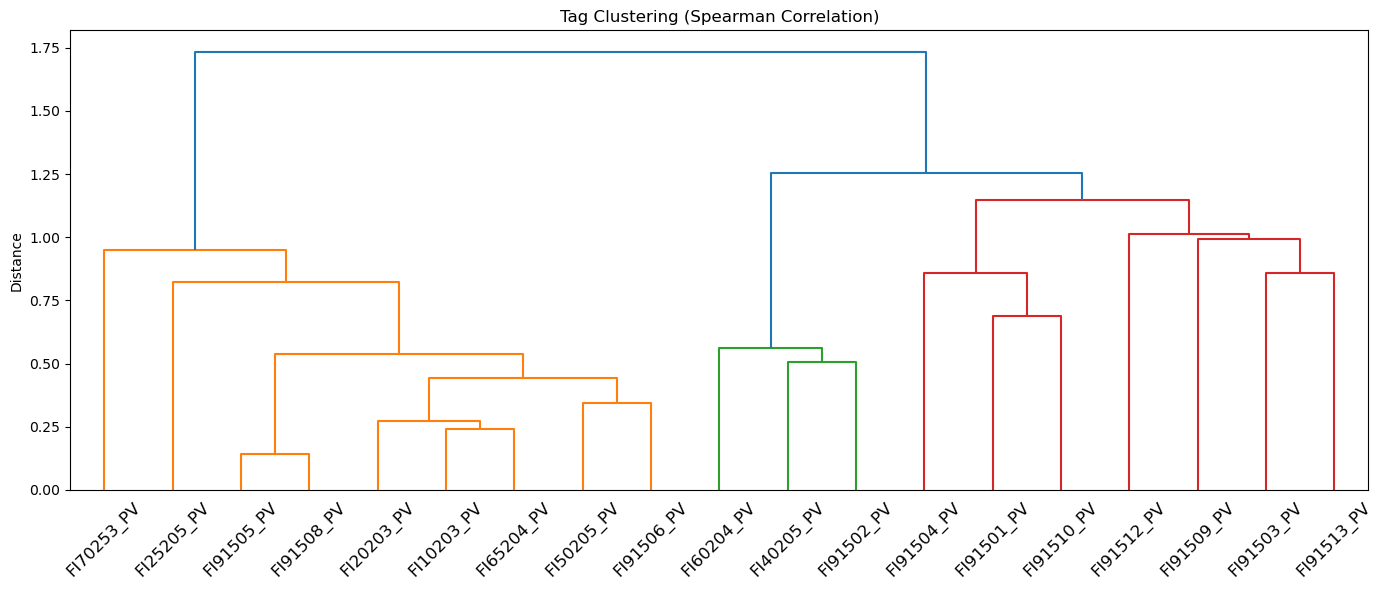

In [27]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

# Correlation-based distance
pivot = utility_data.pivot_table(index='Datetime', columns='TAG', values='Value').dropna()
pivot = pivot.loc[:, pivot.std() > 0.001]  # Remove constant
corr = pivot.corr(method='spearman')

# Convert correlation to distance (1 - |correlation|)
distance = 1 - np.abs(corr)
np.fill_diagonal(distance.values, 0)

# Hierarchical clustering
condensed = squareform(distance)
linked = linkage(condensed, method='ward')

# Plot dendrogram
plt.figure(figsize=(14, 6))
dendrogram(linked, labels=corr.columns, leaf_rotation=45)
plt.title('Tag Clustering (Spearman Correlation)')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [30]:
n_clusters = 4
cluster_labels = fcluster(linked, n_clusters, criterion='maxclust')

cluster_df = pd.DataFrame({
    'TAG': corr.columns,
    'Cluster': cluster_labels
}).sort_values('Cluster')

for c in range(1, n_clusters + 1):
    tags = cluster_df[cluster_df['Cluster'] == c]['TAG'].tolist()
    print(f"Cluster {c}: {tags}")

Cluster 1: ['FI10203_PV', 'FI20203_PV', 'FI25205_PV', 'FI50205_PV', 'FI70253_PV', 'FI65204_PV', 'FI91508_PV', 'FI91506_PV', 'FI91505_PV']
Cluster 2: ['FI40205_PV', 'FI60204_PV', 'FI91502_PV']
Cluster 3: ['FI91501_PV', 'FI91504_PV', 'FI91510_PV']
Cluster 4: ['FI91503_PV', 'FI91509_PV', 'FI91512_PV', 'FI91513_PV']


## Assign cluster labels

In [31]:
# Cut tree into N clusters
n_clusters = 4
cluster_labels = fcluster(linked, n_clusters, criterion='maxclust')

# Create cluster table
cluster_df = pd.DataFrame({
    'TAG': corr.columns,
    'Cluster': cluster_labels
}).sort_values('Cluster')

display(HTML("<h3>Tag Clusters</h3>"))
display(cluster_df)

# Summary
for c in range(1, n_clusters + 1):
    tags = cluster_df[cluster_df['Cluster'] == c]['TAG'].tolist()
    print(f"\nCluster {c}: {tags}")

,TAG,Cluster
0,FI10203_PV,1
1,FI20203_PV,1
2,FI25205_PV,1
4,FI50205_PV,1
7,FI70253_PV,1
6,FI65204_PV,1
14,FI91508_PV,1
13,FI91506_PV,1
12,FI91505_PV,1
3,FI40205_PV,2



Cluster 1: ['FI10203_PV', 'FI20203_PV', 'FI25205_PV', 'FI50205_PV', 'FI70253_PV', 'FI65204_PV', 'FI91508_PV', 'FI91506_PV', 'FI91505_PV']

Cluster 2: ['FI40205_PV', 'FI60204_PV', 'FI91502_PV']

Cluster 3: ['FI91501_PV', 'FI91504_PV', 'FI91510_PV']

Cluster 4: ['FI91503_PV', 'FI91509_PV', 'FI91512_PV', 'FI91513_PV']


## Interactive cluster plot

In [32]:
import plotly.express as px

# Add cluster info to correlation heatmap
cluster_df_sorted = cluster_df.sort_values('Cluster')
sorted_tags = cluster_df_sorted['TAG'].tolist()
corr_sorted = corr.loc[sorted_tags, sorted_tags]

fig = px.imshow(
    corr_sorted,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title='Correlation Matrix (Sorted by Cluster)'
)
fig.update_layout(height=700, width=800)
fig.show()

### Check highly correlated pairs (potential redundancy)

In [33]:
# Find pairs with |correlation| > 0.7
high_corr = []
for i, t1 in enumerate(corr.columns):
    for t2 in corr.columns[i+1:]:
        if abs(corr.loc[t1, t2]) > 0.7:
            high_corr.append({'TAG_1': t1, 'TAG_2': t2, 'Correlation': corr.loc[t1, t2]})

high_corr_df = pd.DataFrame(high_corr).sort_values('Correlation', key=abs, ascending=False)
display(HTML("<h3>Highly Correlated Pairs (|r| > 0.7)</h3>"))
display(high_corr_df)

,TAG_1,TAG_2,Correlation
6,FI91505_PV,FI91508_PV,0.857600
2,FI10203_PV,FI65204_PV,-0.758177
0,FI10203_PV,FI20203_PV,0.756329
5,FI20203_PV,FI91508_PV,-0.730906
1,FI10203_PV,FI50205_PV,-0.718539
4,FI20203_PV,FI65204_PV,-0.714204
3,FI20203_PV,FI50205_PV,-0.703267


## Optimal number of clusters (elbow method)

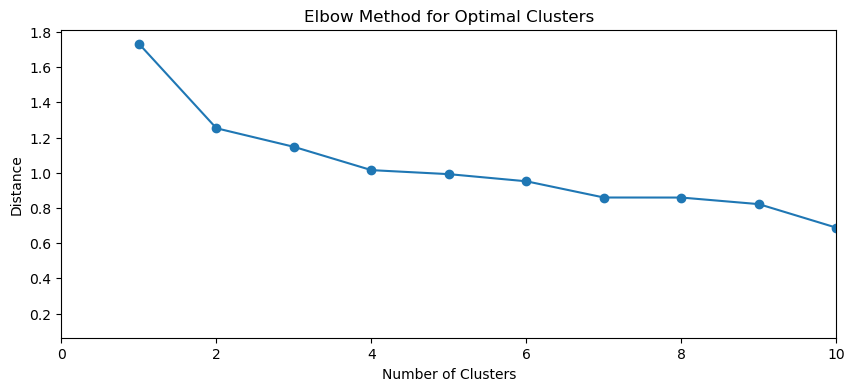

In [34]:
from scipy.cluster.hierarchy import inconsistent

# Calculate inconsistency
depth = 4
incons = inconsistent(linked, depth)

# Plot elbow
distances = linked[:, 2]
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(distances) + 1), distances[::-1], marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Distance')
plt.title('Elbow Method for Optimal Clusters')
plt.xlim(0, 10)
plt.show()

In [50]:
from ipywidgets import Dropdown, interact
import plotly.graph_objects as go
import numpy as np
from scipy import stats

tags = utility_data['TAG'].unique().tolist()
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'cyan', 'magenta', 'lime']

@interact(tag1=Dropdown(options=tags, description='TAG 1:'),
          tag2=Dropdown(options=tags, description='TAG 2:', value=tags[1]))
def plot_scatter(tag1, tag2):
    df1 = utility_data[utility_data['TAG'] == tag1][['Datetime', 'Value']].set_index('Datetime')
    df2 = utility_data[utility_data['TAG'] == tag2][['Datetime', 'Value']].set_index('Datetime')
    merged = df1.join(df2, lsuffix='_1', rsuffix='_2').dropna()
    
    corr_val = merged['Value_1'].corr(merged['Value_2'])
    
    fig = go.Figure()
    
    # Color for tag1
    color1 = colors[tags.index(tag1) % len(colors)]
    
    # Add trendline
    z = np.polyfit(merged['Value_1'], merged['Value_2'], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(merged['Value_1'].min(), merged['Value_1'].max(), 100)
    
    # Calculate confidence interval
    slope, intercept, r_value, p_value, std_err = stats.linregress(merged['Value_1'], merged['Value_2'])
    residuals = merged['Value_2'] - (slope * merged['Value_1'] + intercept)
    std_residuals = np.std(residuals)
    y_upper = p(x_trend) + 1.96 * std_residuals
    y_lower = p(x_trend) - 1.96 * std_residuals
    
    # Color for trendline
    color2 = colors[tags.index(tag2) % len(colors)]
    
    # Add CI band
    fig.add_trace(go.Scatter(x=x_trend, y=y_upper, fill=None, mode='lines', 
                             line_color='rgba(0,0,0,0)', showlegend=False))
    fig.add_trace(go.Scatter(x=x_trend, y=y_lower, fill='tonexty', mode='lines', 
                             line_color='rgba(0,0,0,0)', name='95% CI', 
                             fillcolor='rgba(255,0,0,0.2)'))
    
    # Add trendline
    fig.add_trace(go.Scatter(
        x=x_trend,
        y=p(x_trend),
        mode='lines',
        name='Trendline',
        line=dict(color=color2, width=2)
    ))

    # Add points with colorscale by day
    fig.add_trace(go.Scatter(
        x=merged['Value_1'],
        y=merged['Value_2'],
        mode='markers',
        name=tag1,
        marker=dict(
            size=8, 
            color=merged.index.day, 
            colorscale='Viridis', 
            opacity=0.6,
            colorbar=dict(title="Day of Month")
        )
    ))
    
    fig.update_layout(
        title=f'{tag1} vs {tag2}<br><sup>Correlation: {corr_val:.3f}</sup>',
        xaxis_title=tag1,
        yaxis_title=tag2,
        height=500,
        hovermode='closest',
        plot_bgcolor='rgba(240,240,240,0.5)',
        xaxis=dict(showgrid=True, gridwidth=1, gridcolor='LightGray'),
        yaxis=dict(showgrid=True, gridwidth=1, gridcolor='LightGray'),
        legend=dict(
            x=1.15,
            y=1,
            xanchor='left',
            yanchor='top'
        )
    )
    fig.show()

interactive(children=(Dropdown(description='TAG 1:', options=('FI91501_PV', 'FI91502_PV', 'FI91503_PV', 'FI915…

In [51]:
from scipy import signal

@interact(tag=Dropdown(options=utility_data['TAG'].unique(), description='TAG:'))
def plot_residual(tag):
    df = utility_data[utility_data['TAG'] == tag].sort_values('Datetime')
    values = df['Value'].dropna()
    
    # Detrend (remove linear trend)
    detrended = signal.detrend(values)
    
    fig = make_subplots(rows=2, cols=1, subplot_titles=['Original', 'Detrended (Residual)'])
    fig.add_trace(go.Histogram(x=values, nbinsx=50), row=1, col=1)
    fig.add_trace(go.Histogram(x=detrended, nbinsx=50), row=2, col=1)
    fig.update_layout(height=500, showlegend=False, title=f'{tag} - Residual Distribution')
    fig.show()

interactive(children=(Dropdown(description='TAG:', options=('FI91501_PV', 'FI91502_PV', 'FI91503_PV', 'FI91504…

## PCA:
Type: Linear Dimensionality reduction, feature extraction

In [66]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px

# Prepare data
pivot = utility_data.pivot_table(index='Datetime', columns='TAG', values='Value').dropna()
scaler = StandardScaler()
scaled = scaler.fit_transform(pivot)

# PCA
pca = PCA()
pca_result = pca.fit_transform(scaled)

# Explained variance
exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

fig = px.bar(
    x=range(1, len(exp_var)+1), 
    y=exp_var,
    title='PCA Explained Variance'
)
fig.add_scatter(x=list(range(1, len(cum_var)+1)), y=cum_var, name='Cumulative')
fig.update_layout(xaxis_title='Component', yaxis_title='Variance Ratio')
#fig.update_yaxes(range=[0, 1.05])
fig.show()

print(f"Components for 95% variance: {np.argmax(cum_var >= 0.95) + 1}")

Components for 95% variance: 14


**📌 What This Means for You**

We likely started with ~20 sensors.

But:

We can reduce to ~10 components and still keep ~85% of system information.

For modeling (LSTM / clustering), this reduces noise and multicolarity.

Many sensors are redundant.

## PCA Loadings (which tags matter):

In [54]:
# Top contributors per component
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pivot.columns))],
    index=pivot.columns
)

# Top 5 tags per component
for i in range(3):
    print(f"\n=== PC{i+1} ({exp_var[i]*100:.1f}% variance) ===")
    top = loadings[f'PC{i+1}'].abs().nlargest(5)
    for tag, val in top.items():
        sign = '+' if loadings.loc[tag, f'PC{i+1}'] > 0 else '-'
        print(f"  {sign} {tag}: {val:.3f}")


=== PC1 (26.2% variance) ===
  + FI20203_PV: 0.426
  + FI10203_PV: 0.425
  - FI50205_PV: 0.345
  - FI91508_PV: 0.341
  + FI91506_PV: 0.340

=== PC2 (13.3% variance) ===
  + FI91510_PV: 0.504
  + FI91505_PV: 0.484
  + FI91509_PV: 0.400
  + FI91508_PV: 0.291
  + FI91502_PV: 0.268

=== PC3 (9.7% variance) ===
  + FI40205_PV: 0.516
  + FI91502_PV: 0.432
  - FI60204_PV: 0.356
  - FI70253_PV: 0.343
  - FI91510_PV: 0.283


## PaCMAP

In [55]:
!pip install pacmap -q

In [56]:
import pacmap

# PaCMAP embedding
embedding = pacmap.PaCMAP(n_components=2, n_neighbors=10, MN_ratio=0.5, FP_ratio=2.0)
pacmap_result = embedding.fit_transform(scaled)

# Plot with time coloring
fig = px.scatter(
    x=pacmap_result[:, 0], 
    y=pacmap_result[:, 1],
    color=pivot.index.astype(str),
    title='PaCMAP: Utility Data Over Time'
)
fig.update_layout(showlegend=False)
fig.show()

this cell is about PCA, 

## Compare PCA vs PaCMAP

In [57]:
from plotly.subplots import make_subplots

fig = make_subplots(rows=1, cols=2, subplot_titles=['PCA', 'PaCMAP'])

# Color by time (year-month)
colors = pd.to_datetime(pivot.index).strftime('%Y-%m')

fig.add_trace(go.Scatter(
    x=pca_result[:, 0], y=pca_result[:, 1],
    mode='markers', marker=dict(size=3, color=pd.factorize(colors)[0], colorscale='Viridis'),
    name='PCA'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=pacmap_result[:, 0], y=pacmap_result[:, 1],
    mode='markers', marker=dict(size=3, color=pd.factorize(colors)[0], colorscale='Viridis'),
    name='PaCMAP'
), row=1, col=2)

fig.update_layout(height=400, width=900, title='Dimensionality Reduction Comparison')
fig.show()

## PCA for Tag Clustering

In [58]:
# Find common tags
pivot_tags = set(pivot.columns)
cluster_tags = set(cluster_df['TAG'].values)

print(f"In pivot but not in cluster_df: {pivot_tags - cluster_tags}")
print(f"In cluster_df but not in pivot: {cluster_tags - pivot_tags}")

# Use only common tags
common_tags = list(pivot_tags & cluster_tags)
pivot_common = pivot[common_tags]

# Re-run PCA
scaler = StandardScaler()
scaled_common = scaler.fit_transform(pivot_common)

pca_tags = PCA(n_components=2)
tag_coords = pca_tags.fit_transform(scaled_common.T)

# Plot
cluster_colors = cluster_df.set_index('TAG').loc[common_tags, 'Cluster'].astype(str)

fig = px.scatter(
    x=tag_coords[:, 0], 
    y=tag_coords[:, 1],
    text=common_tags,
    color=cluster_colors.values,
    title='Tags in PCA Space (colored by cluster)'
)
fig.update_traces(textposition='top center')
fig.update_layout(height=600, width=800)
fig.show()

In pivot but not in cluster_df: {'FI91507_PV'}
In cluster_df but not in pivot: set()


In [59]:
from scipy.spatial.distance import cdist

# Find points far from center
center = pacmap_result.mean(axis=0)
distances = cdist(pacmap_result, [center]).flatten()
threshold = np.percentile(distances, 99)

outlier_idx = np.where(distances > threshold)[0]
outlier_dates = pivot.index[outlier_idx]

print(f"Outliers detected: {len(outlier_idx)}")
print(f"Dates: {outlier_dates.tolist()[:10]}...")

Outliers detected: 281
Dates: [Timestamp('2023-01-24 18:00:00'), Timestamp('2023-02-26 12:00:00'), Timestamp('2023-02-26 13:00:00'), Timestamp('2023-02-26 15:00:00'), Timestamp('2023-02-26 16:00:00'), Timestamp('2023-02-26 17:00:00'), Timestamp('2023-02-26 18:00:00'), Timestamp('2023-02-26 19:00:00'), Timestamp('2023-02-26 22:00:00'), Timestamp('2023-02-26 23:00:00')]...


### Analyze outlier distribution

In [60]:
# Group outliers by date
outlier_df = pd.DataFrame({'Datetime': outlier_dates})
outlier_df['Date'] = outlier_df['Datetime'].dt.date
outlier_counts = outlier_df['Date'].value_counts().head(15)

print("Top 15 dates with most outliers:")
print(outlier_counts)

Top 15 dates with most outliers:
Date
2023-03-10    22
2023-03-12    22
2023-03-11    22
2025-06-24    20
2025-06-23    20
2025-06-22    18
2025-06-21    18
2023-02-27    16
2023-03-01    13
2023-03-02    13
2023-02-28    13
2023-03-09    13
2023-03-13    12
2023-03-03    11
2023-03-05    11
Name: count, dtype: int64


### Visualize outliers on timeline

In [61]:
import plotly.express as px

# Mark outliers
outlier_flags = pd.Series(0, index=pivot.index)
outlier_flags.iloc[outlier_idx] = 1

fig = px.scatter(
    x=pivot.index, 
    y=outlier_flags,
    title='Outlier Distribution Over Time'
)
fig.update_layout(yaxis_title='Is Outlier', xaxis_title='Date')
fig.show()

### Check what happened during outliers (one example)

In [62]:
# Look at April 22, 2023
sample_date = '2023-04-22'
sample_data = pivot.loc[sample_date]

fig = px.line(
    sample_data,
    title=f'Tag Values on {sample_date} (Outlier Day)'
)
fig.update_layout(xaxis_title='Time', yaxis_title='Value')
fig.show()

### Create outlier flag for LSTM

In [63]:
# Add outlier column
pivot['is_outlier'] = 0
pivot.loc[pivot.index[outlier_idx], 'is_outlier'] = 1

print(f"Outlier flag created: {pivot['is_outlier'].sum()} marked")

Outlier flag created: 281 marked


In [64]:
quality = pd.DataFrame({
    "missing_%": pivot.isna().mean() * 100,
    "zero_%": (pivot == 0).mean() * 100,
    "std": pivot.std(),
    "min": pivot.min(),
    "max": pivot.max()
}).sort_values("missing_%", ascending=False)

quality.head(10)


,missing_%,zero_%,std,min,max
TAG,,,,,
FI10203_PV,0.0,0.000000,318.025376,53.097755,1132.289429
FI20203_PV,0.0,0.032042,198.323029,0.000000,927.033020
FI25205_PV,0.0,0.081886,83.417657,0.000000,1068.363892
FI40205_PV,0.0,0.060524,73.408359,0.000000,1174.555664
FI50205_PV,0.0,0.106807,421.389596,0.000000,3770.658691
FI60204_PV,0.0,0.081886,211.267071,0.000000,1634.450439
FI65204_PV,0.0,0.000000,140.439252,100.031029,1013.020996
FI70253_PV,0.0,0.000000,502.117348,293.949066,2312.875977
FI91501_PV,0.0,0.000000,97.786535,326.168701,1942.229004
